In [2]:
# =============================================================================
# IMPORTS
# =============================================================================
# numpy       : numerical arrays and math
# matplotlib  : plotting (cm module for colormaps)
# termcolor   : coloured terminal output for progress messages
#               → install once with: pip install termcolor
# pandas      : tabular data structures
# scipy       : curve_fit (available for optional fitting tasks)
# =============================================================================
#### Don't forget to install the termcolor package before using this script ;)
import numpy as np
import matplotlib.pyplot as plt
from termcolor import colored
from matplotlib import cm
%matplotlib inline
import pandas as pd
from scipy.optimize import curve_fit


In [3]:
# =============================================================================
# USER PARAMETERS — edit before running
# =============================================================================
# date_savename : date string prepended to every output file name
# save_path     : directory where figures are written
#                 Use a relative path (e.g. "./output/FigS15/") or an
#                 absolute path appropriate for your system.
# =============================================================================
from tkinter import Tk, filedialog

############################################
#### Set parameters 

date_savename = '260827'
save_path = "./output/FigS15/"



In [4]:
# =============================================================================
# PHYSICS MODEL — Stokes sedimentation of a spherical GUV
# =============================================================================
# Two variants of the same force balance (see also LeastSquare.ipynb):
#
#   free_fall()
#       Full solution including the transient exponential term that captures
#       the brief acceleration phase.  For µm-sized vesicles in water the
#       time constant τ = v_E / g is on the order of microseconds, so this
#       term is numerically negligible but physically complete.
#
#   free_fall_endvelocity()
#       Terminal-velocity approximation: x(t) = x0 − v_E · t.
#       Equivalent to free_fall() for all experimentally relevant time scales.
#
# Force balance:
#   Gravity–buoyancy:  F_net = Δρ · (4/3)π r³ · g_eff
#   Stokes drag:       F_R   = 6π η r v
#   Terminal velocity: v_E   = F_net / (6π η r)
#
# The gravity multiplier g is set to 1 for normal gravity or 8.3 for 200 rpm
# centrifugation (see exp_parameters()).
#
# All inputs must be in SI units (m, kg, Pa·s, s); heights are returned in
# the same units and converted to mm by the calling functions.
# =============================================================================
def free_fall(x0, v0, g, r, visc, rho_guv, rho_medium, t):
    """ x0:         starting height
        v0:         starting velocity
        g:          gravitational acceleration
        r :         radius of vesicle
        visc:       viscosity of outer medium
        rho_guv:    mass density of GUV
        rho_medium: mass density of medium
    """
    
    #### Gravitational acceleration g
    #### Change prefactor to simulate centrifugation
    Fg = g * 9.80665 # in m/s^2
    
    #### Stokes law: 
    #### F_R = 6*pi*radius*viscosity*velocity, 
    #### K = F_R/v
    K = 6 * np.pi*r*visc
    
    #### Free fall of sphere of radius r with density rho_guv in medium with density rho_medium
    #### F_down = F_gravity-F_buoyancy=(density_GUV-density_medium)* (4/3) * pi * r^3 * g
    #### A = F_down/g
    A = (rho_guv-rho_medium)*(4/3)*np.pi*(r**3)
    
    #### End velocity 
    v_E = A * Fg/K
    
    #### Position at time t
    x_t = x0 - (v_E*t) + (v0+v_E)*(v_E/Fg)*(1-np.exp(-Fg*t/v_E))
    #### According to Bartelmann Theoretical Physics 1 script: https://heibox.uni-heidelberg.de/f/7423ef45990149818ef9/
    #### But apparently the (1-np.exp...) is not needed and only relevant for tiny time scales....
    
    return x_t


def free_fall_endvelocity(x0, v0, g, r, visc, rho_guv, rho_medium, t):
    """ x0:         starting height
        v0:         starting velocity
        r :         radius of vesicle
        visc:       viscosity of outer medium
        rho_guv:    mass density of GUV
        rho_medium: mass density of medium
    """
    
    #### Gravitational acceleration g
    Fg = g * 9.80665 # in m/s^2
    
    #### Stokes law: 
    #### F_R = 6*pi*radius*viscosity*velocity, 
    #### K = F_R/v
    K = 6*np.pi*r*visc
    
    #### Free fall of sphere of radius r with density rho_guv in medium with density rho_medium
    #### F_down = F_gravity-F_buoyancy=(density_GUV-density_medium)* (4/3) * pi * r^3 * g
    #### A = F_down/g
    A = (rho_guv-rho_medium)*(4/3)*np.pi*(r**3)
    
    #### End velocity 
    v_E = A*Fg/K
    
    #### Position at time t
    x_t = x0 - (v_E*t)
    #### According to Bartelmann Theoretical Physics 1 script: https://heibox.uni-heidelberg.de/f/7423ef45990149818ef9/
    #### This time without the complicated exponential
    
    
    return x_t

In [ ]:
# =============================================================================
# EXPERIMENT PARAMETER FACTORY — exp_parameters()
# =============================================================================
# Extended version of the parameter factory that additionally supports:
#   • Centrifugation:  centrifuge='200rpm' → g = 8.3 × Earth gravity
#                      centrifuge='0rpm'   → g = 1   (gravity only)
#   • Salt media:      'NaCl' (ρ = 1001 kg/m³, η = 1.012 mPa·s)
#                      'RbCl' (ρ = 1006 kg/m³, η = 0.999 mPa·s)
#                      (in addition to the sugar solutions raffinose/sucrose/glucose)
#   • RbCl inner medium (denser salt solution encapsulated in GUV)
#
# ACCUM_FACTOR:
#   Scales the inner-medium density to model solute accumulation inside the
#   GUV over time.  The 0.696 kg/m³ offset accounts for the lipid bilayer mass.
#
# Channel vs. tube geometry:
#   'channel': x0 = 0.4 mm + max_radius  (µ-slide imaging channel)
#   'tube':    x0 = 20 mm  + max_radius  (Eppendorf / centrifuge tube)
#   Adding max_radius ensures that no GUV starts below its own radius.
#
# Starting heights: nb_starting_heights positions drawn either randomly
#   ('random') or linearly spaced ('linear') between min_radius and x0.
#
# Returns a 11-tuple:
#   (radii, time, heightscale, x0, v0, g, visc, rho_guv, rho_medium,
#    savename, titlename)
#   savename/titlename are auto-generated strings encoding all parameters
#   for unambiguous file naming and plot titles.
# =============================================================================
def exp_parameters( OUTERMED, centrifuge='200rpm', INNERMED='raff',TUBE_OR_CHANNEL='channel', HEIGHTSCALE='random', TIMEFRAME='30min', ACCUM_FACTOR=1.005, save_path = save_path, date_savename = date_savename ):

    nb_starting_heights = 20
    #nb_starting_heights = 100

    min_radius = 1
    max_radius = 25 # in um
    nb_radii = 15

    if centrifuge == '200rpm':
        g = 8.3
    if centrifuge == '0rpm':
        g = 1


    v0 = 0

    rho_raff = 1058 
    rho_sucr = 1032
    rho_gluc = 1023

    #rho_NaCl = 1002
    #rho_RbCl = 1010

    rho_RbCl = 1006
    rho_NaCl = 1001
    #1.00585         #https://advancedthermo.com/electrolytes/density_RbCl.html
    #1.00116         #https://advancedthermo.com/electrolytes/density_NaCl_Jun2021.html 


    #visc_NaCl = 0.90 #mPas
    #visc_RbCl = 0.92 #mPas

    visc_NaCl = 1.012 #mPas
    visc_RbCl = 0.999 #mPas    

    visc_gluc = 1.129 #mPas
    visc_suc = 1.279 #mPas
    visc_raff = 1.433 #mPas 


    x0_channel = 0.0004 + max_radius*10**-6 # in meters
    x0_tube = 0.020 + max_radius*10**-6# in meters

    if INNERMED == 'RbCl':
        rho_guv = ACCUM_FACTOR * rho_RbCl + 0.696
    if INNERMED == 'raff':
        rho_guv = ACCUM_FACTOR * rho_raff + 0.696
    if INNERMED == 'sucr':
        rho_guv = ACCUM_FACTOR * rho_sucr + 0.696

    if INNERMED == 'gluc':
        rho_guv = ACCUM_FACTOR * rho_gluc + 0.696

    if OUTERMED == 'NaCl':
        rho_medium = rho_NaCl
        visc = visc_NaCl
    
    if OUTERMED == 'RbCl':
        rho_medium = rho_RbCl
        visc = visc_RbCl
        
    if OUTERMED == 'raff':
        rho_medium = rho_raff
        visc = visc_raff
    if OUTERMED == 'sucr':
        rho_medium = rho_sucr
        visc = visc_suc
    if OUTERMED == 'gluc':  
        rho_medium = rho_gluc
        visc = visc_gluc
        
    if TUBE_OR_CHANNEL == 'tube':
        x0 = x0_tube
    if TUBE_OR_CHANNEL == 'channel':
        x0 = x0_channel

    if TIMEFRAME == '30min':
        time = np.linspace(0,1800,1000) 
    if TIMEFRAME == '1h':
        time = np.linspace(0,3600,3600) 
    if TIMEFRAME == '3.5h':
        time = np.linspace(0,12600,12600) 
    if TIMEFRAME == '12h':
        time = np.linspace(0,43200,1000)
    if TIMEFRAME == '24h': 
        time = np.linspace(0,86400,1000)  # in seconds


    randomheights = np.random.uniform(min_radius*10**-6, x0-max_radius*10**-6, nb_starting_heights) # in m
    linearheights = np.linspace(min_radius*10**-6, x0-max_radius*10**-6, nb_starting_heights)

    if HEIGHTSCALE == 'random':
        heightscale = randomheights
    elif HEIGHTSCALE == 'linear':
        heightscale = linearheights



    radii=np.linspace(min_radius,max_radius,nb_radii) #in um

    titlename = f'{INNERMED} in {OUTERMED}, {centrifuge}'
    savename = f'{save_path}/{date_savename}_centrifuge{centrifuge}_{TIMEFRAME}_inner{INNERMED}_outer{OUTERMED}_z0{TUBE_OR_CHANNEL}_{HEIGHTSCALE}um'
    
    return radii, time, heightscale, x0, v0, g, visc, rho_guv, rho_medium, savename, titlename

In [ ]:
# =============================================================================
# VISUALIZATION — plot_sedimentation()
# =============================================================================
# Plots the height trajectory x(t) of every simulated GUV as a coloured line.
# Colour encodes GUV radius via the viridis colormap (small → dark, large → yellow).
#
# Layout: 2-panel figure
#   Left panel  : height [mm] vs. time [min] for all (radius, start-height) pairs
#   Right panel : colour bar mapping radius [µm] to colour
#
# A trajectory that reaches the x-axis (height = 0) represents a GUV that has
# settled to the glass bottom within the simulated time window.
# Faster-settling (larger or denser) GUVs produce steeper, earlier-arriving lines.
#
# The figure is saved as PNG to savename (auto-generated by exp_parameters()).
# =============================================================================

def plot_sedimentation(EXP_PARAMETERS):
    radii, time, heightscale, x0, v0, g, visc, rho_guv, rho_medium, savename, titlename = EXP_PARAMETERS

    norm = cm.colors.Normalize(vmax=radii.max(), vmin=radii.min())
    cmap = cm.viridis
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(3, 3),
                                   gridspec_kw={'width_ratios': [15, 1]})

    color_list=[]
    y_list=[]
    for radius in radii:
        r=radius*1e-06 # in m
        for z in heightscale:
            y_data = {
                'Radius': radius,
                'Initial_Height': z,
                'Time': time,
                'Height': [1e+03 * free_fall(z, v0, g, r, visc, rho_guv, rho_medium, timepoint) for timepoint in time]
            }
            y_list.append(pd.DataFrame(y_data))

            color_list.append(cmap(radius/radii.max())) 

    #### Plot traces with specified color
    for i in range(len(y_list)):
        for j in range(len(heightscale)):
            mins=[timepoint/60 for timepoint in time]
            ax1.plot(mins,y_list[i]['Height'],color=color_list[i])

    ax1.set_ylim(0,1.01*1e+03*x0)
    ax1.set_ylabel("Height [mm]")
    ax1.set_xlabel("Time [min]")
    map = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    ax1.set_title(titlename)
    
    # Add colorbar
    cbar = plt.colorbar(map, cax=ax2, ticks=radii, label='Radius [µm]')
    cbar.ax.set_yticklabels([f'{int(radius)}' for radius in radii])
    plt.savefig(savename+'.png', dpi=300, bbox_inches='tight')
    plt.show()



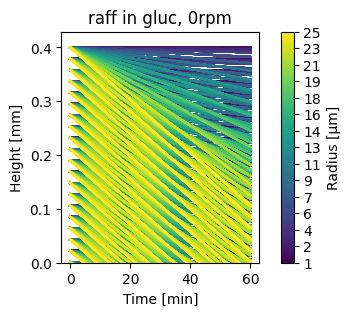

In [7]:
# Example 1: Gravity-only settling (0 rpm) of raffinose-loaded GUVs in glucose
# medium inside a µ-slide channel over 1 hour.
# This represents the baseline buoyancy-driven sedimentation without centrifugation.
plot_sedimentation(exp_parameters(OUTERMED='gluc', 
                                  centrifuge='0rpm', 
                                  INNERMED='raff',
                                  TUBE_OR_CHANNEL='channel', 
                                  HEIGHTSCALE='linear', 
                                  TIMEFRAME='1h', 
                                  ACCUM_FACTOR=1.03, 
                                  save_path = save_path, 
                                  date_savename = date_savename))

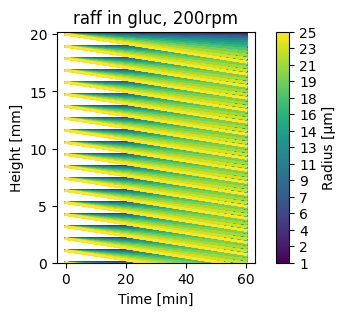

In [13]:
# Example 2: Centrifugation at 200 rpm of raffinose-loaded GUVs in glucose
# medium inside an Eppendorf tube over 1 hour.
# Compare with Example 1 to see the ~8× speed-up from centrifugation.
plot_sedimentation(exp_parameters(OUTERMED='gluc', 
                                  centrifuge='200rpm', 
                                  INNERMED='raff',
                                  TUBE_OR_CHANNEL='tube', 
                                  HEIGHTSCALE='linear', 
                                  TIMEFRAME='1h', 
                                  ACCUM_FACTOR=1.03, 
                                  save_path = save_path, 
                                  date_savename = date_savename))

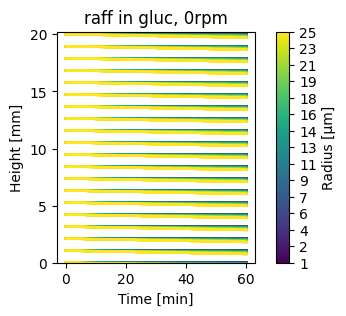

In [14]:
# Example 3: Gravity-only settling inside a tube (20 mm height) — same
# chemistry as Example 1 but larger container. Most GUVs do not reach the
# bottom within 1 hour due to the much larger settling distance.
plot_sedimentation(exp_parameters(OUTERMED='gluc', 
                                  centrifuge='0rpm', 
                                  INNERMED='raff',
                                  TUBE_OR_CHANNEL='tube', 
                                  HEIGHTSCALE='linear', 
                                  TIMEFRAME='1h', 
                                  ACCUM_FACTOR=1.03, 
                                  save_path = save_path, 
                                  date_savename = date_savename))

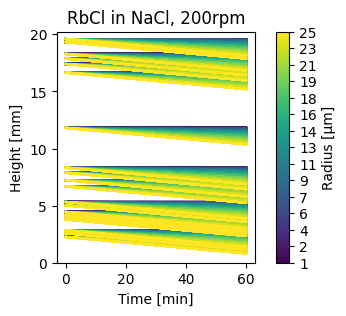

In [7]:
# Example 4: Centrifugation at 200 rpm with RbCl encapsulated inside GUVs
# suspended in NaCl outer medium inside a tube.
# RbCl is denser than NaCl, so GUVs are net-dense and sediment downward.
# This condition tests an alternative ion-based density contrast.
plot_sedimentation(exp_parameters(OUTERMED='NaCl', 
                                  centrifuge='200rpm', 
                                  INNERMED='RbCl',
                                  TUBE_OR_CHANNEL='tube', 
                                  HEIGHTSCALE='random', 
                                  TIMEFRAME='1h', 
                                  ACCUM_FACTOR=1.03,
                                  save_path = save_path, 
                                  date_savename = date_savename))

In [ ]:
# =============================================================================
# VISUALIZATION — plot_arrival_cumulative()
# =============================================================================
# Plots a cumulative histogram of GUV arrival times at the glass bottom for a
# single experimental condition.
#
# Algorithm:
#   For each (radius, starting_height) trajectory, find the first time point
#   at which the corrected height (x(t) + x0) crosses zero.  Collect all such
#   arrival times and bin them into a cumulative histogram.
#
# The cumulative curve shows how many GUVs have settled by each time point,
# which can be directly compared to experimental counting data.
#
# =============================================================================
def plot_arrival_cumulative(EXP_PARAMETERS):
    
    arrival_time_list = []


    radii, time, heightscale, x0, v0, g, visc, rho_guv, rho_medium = EXP_PARAMETERS
    norm = cm.colors.Normalize(vmax=radii.max(), vmin=radii.min())
    cmap = cm.viridis
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 5),
                                   gridspec_kw={'width_ratios': [15, 1]})

    ax2.axis('off')
    
    color_list=[]
    y_list=[]
    for radius in radii:
        r=radius*1e-06 # in m
        for z in heightscale:
            y_data = {
                'Radius': radius,
                'Initial_Height': z,
                'Time': time,
                'Height': [1e+03 * free_fall(z, v0, g, r, visc, rho_guv, rho_medium, timepoint) for timepoint in time]
            }
            y_list.append(pd.DataFrame(y_data))

            color_list.append(cmap(radius/radii.max())) 


    # Iterate through each entry in y_list
    for entry in y_list:
        # Add x0 to the 'Height' values
        entry['Height'] += x0
        times_of_GUV_arrival = entry.loc[entry['Height'] < 0, 'Time']
        if not times_of_GUV_arrival.empty:
            time_of_first_GUV_arrival = times_of_GUV_arrival.iloc[0]
            arrival_time_list.append(time_of_first_GUV_arrival)
            time_of_GUV_arrival_list_mins = [time / 60 for time in arrival_time_list]


    bins = np.linspace(0, entry['Time'].max() / 60, 11)
    ax1.hist(time_of_GUV_arrival_list_mins, bins=bins, color='blue', alpha=0.7, edgecolor='black', cumulative=True)

    ax1.set_title("Abundance of GUVs arriving at glass surface over time")
    ax1.set_xlabel("Time [min]")
    ax1.set_ylabel("Number of GUVs")
    ax1.grid(axis='y', alpha=0.75)

    #plt.savefig(date_savename+'_'+EXPERIMENT+"_visc"+visc_savename+"_rhoGUV"+rhoinner_savename+"_rhomed"+rhomed_savename+"_z0_"+height_savename+"um"+'_hist'+".png", dpi=300)

    plt.show()

In [ ]:
# =============================================================================
# VISUALIZATION — plot_3_sedimentation()
# =============================================================================
# Side-by-side version of plot_sedimentation() for three conditions at once.
# Useful for directly comparing how different g-forces, media viscosities, or
# density contrasts affect the settling speed and time-to-arrival.
#
# Layout: three trajectory panels sharing a single viridis colour bar on the
# right, each titled with the applied g-force of that condition.
# =============================================================================
def plot_3_sedimentation(EXP1_PARAMETERS, EXP2_PARAMETERS, EXP3_PARAMETERS):   
    
    radii1to3 = [EXP1_PARAMETERS[0], EXP2_PARAMETERS[0], EXP3_PARAMETERS[0]]
    time1to3 = [EXP1_PARAMETERS[1], EXP2_PARAMETERS[1], EXP3_PARAMETERS[1]]
    heightscale1to3 = [EXP1_PARAMETERS[2], EXP2_PARAMETERS[2], EXP3_PARAMETERS[2]]
    x01to3 = [EXP1_PARAMETERS[3], EXP2_PARAMETERS[3], EXP3_PARAMETERS[3]]
    v01to3 = [EXP1_PARAMETERS[4], EXP2_PARAMETERS[4], EXP3_PARAMETERS[4]]
    g1to3 = [EXP1_PARAMETERS[5], EXP2_PARAMETERS[5], EXP3_PARAMETERS[5]]
    visc1to3 = [EXP1_PARAMETERS[6], EXP2_PARAMETERS[6], EXP3_PARAMETERS[6]]
    rho_guv1to3 = [EXP1_PARAMETERS[7], EXP2_PARAMETERS[7], EXP3_PARAMETERS[7]]
    rho_medium1to3 = [EXP1_PARAMETERS[8], EXP2_PARAMETERS[8], EXP3_PARAMETERS[8]]



    


    fig, (ax1, ax2, ax3, cax) = plt.subplots(1, 4, figsize=(15, 5), 
                                            gridspec_kw={'width_ratios': [15, 15, 15, 1]})


    for k, ax in enumerate([ax1, ax2, ax3]):
        g = g1to3[k]
        x0 = x01to3[k]
        radii = radii1to3[k]
        time = time1to3[k]
        heightscale = heightscale1to3[k]
        v0 = v01to3[k]
        visc = visc1to3[k]
        rho_inner = rho_guv1to3[k]
        rho_medium = rho_medium1to3[k]
        norm = cm.colors.Normalize(vmax=radii.max(), vmin=radii.min())
        cmap = cm.viridis
        color_list=[]
        y_list=[]
        for radius in radii:
            r=radius*1e-06 # in m
            for z in heightscale:
                y_data = {
                    'Radius': radius,
                    'Initial_Height': z,
                    'Time': time,
                    'Height': [1e+03 * free_fall(z, v0, g, r, visc, rho_inner, rho_medium, timepoint) for timepoint in time]
                }
                y_list.append(pd.DataFrame(y_data))
                
                color_list.append(cmap(radius/radii.max())) 
        for i in range(len(y_list)):
            for j in range(len(heightscale)):
                mins=[timepoint/60 for timepoint in time]
                ax.plot(mins,y_list[i]['Height'],color=color_list[i])

        ax.set_ylim(0, 1.1 * 1e+03 * x0)
        ax.set_ylabel("Height [mm]")
        ax.set_xlabel("Time [min]")
        ax.set_title('Applied g force: ' + str(g))

    # Add colorbar to the last axis
    map = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    cbar = plt.colorbar(map, cax=cax, ticks=radii, label='Radius [µm]')
    cbar.ax.set_yticklabels([f'{int(radius)}' for radius in radii])

    plt.tight_layout()
    #plt.savefig(date_savename+'_'+EXPERIMENT+'_'+g_savename+"g_visc"+visc_savename+"_rhoGUV"+rhoinner_savename+"_rhomed"+rhomed_savename+"_z0_"+height_savename+"um"+".png", dpi=300)

    plt.show()

In [12]:
# =============================================================================
# VISUALIZATION — plot_3_arrival_cumulative()
# =============================================================================
# Side-by-side cumulative arrival histograms for three conditions.
# Each panel shows the number of GUVs that have settled by each time point
# under a different set of physical parameters (typically different g-forces).
#
# Key detail: entry['Height'] += x0 shifts the coordinate origin so that
# height = 0 corresponds to the glass bottom; a GUV has arrived when the
# corrected height first becomes negative.
# =============================================================================
def plot_3_arrival_cumulative(EXP1_PARAMETERS, EXP2_PARAMETERS, EXP3_PARAMETERS):   
    
    radii1to3 = [EXP1_PARAMETERS[0], EXP2_PARAMETERS[0], EXP3_PARAMETERS[0]]
    time1to3 = [EXP1_PARAMETERS[1], EXP2_PARAMETERS[1], EXP3_PARAMETERS[1]]
    heightscale1to3 = [EXP1_PARAMETERS[2], EXP2_PARAMETERS[2], EXP3_PARAMETERS[2]]
    x01to3 = [EXP1_PARAMETERS[3], EXP2_PARAMETERS[3], EXP3_PARAMETERS[3]]
    v01to3 = [EXP1_PARAMETERS[4], EXP2_PARAMETERS[4], EXP3_PARAMETERS[4]]
    g1to3 = [EXP1_PARAMETERS[5], EXP2_PARAMETERS[5], EXP3_PARAMETERS[5]]
    visc1to3 = [EXP1_PARAMETERS[6], EXP2_PARAMETERS[6], EXP3_PARAMETERS[6]]
    rho_guv1to3 = [EXP1_PARAMETERS[7], EXP2_PARAMETERS[7], EXP3_PARAMETERS[7]]
    rho_medium1to3 = [EXP1_PARAMETERS[8], EXP2_PARAMETERS[8], EXP3_PARAMETERS[8]]



    

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(1, 4, figsize=(15, 5), 
                                            gridspec_kw={'width_ratios': [15, 15, 15, 1]})

    ax4.axis('off')

    for k, ax in enumerate([ax1, ax2, ax3]):
        g = g1to3[k]
        x0 = x01to3[k]
        radii = radii1to3[k]
        time = time1to3[k]
        heightscale = heightscale1to3[k]
        v0 = v01to3[k]
        visc = visc1to3[k]
        rho_inner = rho_guv1to3[k]
        rho_medium = rho_medium1to3[k]
        norm = cm.colors.Normalize(vmax=radii.max(), vmin=radii.min())
        cmap = cm.viridis
        color_list=[]
        y_list=[]
        arrival_time_list = []

        for radius in radii:
            r=radius*1e-06 # in m
            for z in heightscale:
                y_data = {
                    'Radius': radius,
                    'Initial_Height': z,
                    'Time': time,
                    'Height': [1e+03 * free_fall(z, v0, g, r, visc, rho_inner, rho_medium, timepoint) for timepoint in time]
                }
                y_list.append(pd.DataFrame(y_data))
        # List to store the time when height becomes negative
        # Iterate through each entry in y_list
        for entry in y_list:
        # Add x0 to the 'Height' values
            entry['Height'] += x0
        # Find the first 'Time' where 'Height' is negative
            arrival_time = entry.loc[entry['Height'] < 0, 'Time'].min()
        # Append the time to the list if it exists
            if not pd.isna(arrival_time):
                arrival_time_list.append(arrival_time)
                # Convert time to hours for plotting
                arrival_time_list_mins = [time / 60 for time in arrival_time_list]
                # Plot histogram of the abundance of 'Time' in hours
        
        # Plot histogram of the abundance of 'Time'

        bins = np.linspace(0, entry['Time'].max() / 60, 31)
        ax.hist(arrival_time_list_mins, bins=bins, color='blue', alpha=0.7, edgecolor='black', cumulative=True)

        ax.set_ylim(0, len(radii) * len(heightscale))
        ax.set_title('Applied g force: ' + str(g))
        ax.set_xlabel('Time [min]')
        ax.set_ylabel('Number of GUVs')

    plt.tight_layout()
    #plt.savefig(date_savename+'_'+EXPERIMENT+'_'+g_savename+"g_visc"+visc_savename+"_rhoGUV"+rhoinner_savename+"_rhomed"+rhomed_savename+"_z0_"+height_savename+"um"+'_hist'+".png", dpi=300)
    plt.show()


In [14]:
# =============================================================================
# VISUALIZATION — plot_3_arrival_cumulative_together()
# =============================================================================
# Overlays the cumulative arrival curves for three conditions on a single axis
# for direct quantitative comparison (as opposed to the side-by-side layout
# in plot_3_arrival_cumulative).
#
# Time axis is in hours (not minutes) to accommodate longer time scales.
# The figure is saved as PDF to save_path.
#
# Typical use: compare arrival kinetics of GUVs in raffinose, sucrose, and
# glucose outer media under the same g-force and geometry.
# =============================================================================
def plot_3_arrival_cumulative_together(EXP1_PARAMETERS, EXP2_PARAMETERS, EXP3_PARAMETERS, savename):
    
        
    radii1to3 = [EXP1_PARAMETERS[0], EXP2_PARAMETERS[0], EXP3_PARAMETERS[0]]
    time1to3 = [EXP1_PARAMETERS[1], EXP2_PARAMETERS[1], EXP3_PARAMETERS[1]]
    heightscale1to3 = [EXP1_PARAMETERS[2], EXP2_PARAMETERS[2], EXP3_PARAMETERS[2]]
    x01to3 = [EXP1_PARAMETERS[3], EXP2_PARAMETERS[3], EXP3_PARAMETERS[3]]
    v01to3 = [EXP1_PARAMETERS[4], EXP2_PARAMETERS[4], EXP3_PARAMETERS[4]]
    g1to3 = [EXP1_PARAMETERS[5], EXP2_PARAMETERS[5], EXP3_PARAMETERS[5]]
    visc1to3 = [EXP1_PARAMETERS[6], EXP2_PARAMETERS[6], EXP3_PARAMETERS[6]]
    rho_guv1to3 = [EXP1_PARAMETERS[7], EXP2_PARAMETERS[7], EXP3_PARAMETERS[7]]
    rho_medium1to3 = [EXP1_PARAMETERS[8], EXP2_PARAMETERS[8], EXP3_PARAMETERS[8]]


    fig, ax = plt.subplots(figsize=(3, 4))

    # Iterate through each condition

    for k in [0,1,2]:
        cond_name = savename[k]
        g = g1to3[k]
        x0 = x01to3[k]
        radii = radii1to3[k]
        time = time1to3[k]
        heightscale = heightscale1to3[k]
        v0 = v01to3[k]
        visc = visc1to3[k]
        rho_inner = rho_guv1to3[k]
        rho_medium = rho_medium1to3[k]

        arrival_time_list = []

        # Calculate the arrival time list for each g condition
        for radius in radii:
            r = radius * 1e-06  # in m
            for z in heightscale:
                y_data = {
                    'Radius': radius,
                    'Initial_Height': z,
                    'Time': time,
                    'Height': [1e+03 * free_fall(z, v0, g, r, visc, rho_inner, rho_medium, timepoint) for timepoint in time]
                }
                entry = pd.DataFrame(y_data)
                entry['Height'] += x0
                negative_time = entry.loc[entry['Height'] < 0, 'Time'].min()
                if not pd.isna(negative_time):
                    arrival_time_list.append(negative_time)

        # Convert times to hours
        arrival_time_list_hours = [time / 3600 for time in arrival_time_list]

        # Plot cumulative histogram
        
        bins = np.linspace(0, entry['Time'].max() / 3600, 11)
        hist_values, bin_edges = np.histogram(arrival_time_list_hours, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        cumulative_hist_values = np.cumsum(hist_values)

        
        ax.plot(bin_centers, cumulative_hist_values, label=str(cond_name), alpha=0.7)
    # Add labels, legend, and title
    ax.set_title("Cumulative number of GUVs arriving over time")
    ax.set_xlabel("Time [h]")
    #ax.set_ylim(-1, 25)
    ax.set_ylabel("Cumulative number of GUVs")
    ax.legend()
    ax.tick_params(direction='in')

    # Save and show the plot
    plt.savefig(f'{save_path}/{date_savename}Sim_arriving_GUVs.pdf', dpi=300)
    plt.show()

In [19]:
# Example call for plot_3_arrival_cumulative_together() — currently commented
# out.  Uncomment and set ACCUM_FACTOR to run.
#ACCUM_FACTOR=1.03
#plot_3_arrival_cumulative_together(exp_parameters('raff', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('sucr', ACCUM_FACTOR=ACCUM_FACTOR), exp_parameters('gluc', ACCUM_FACTOR=ACCUM_FACTOR), ['raff', 'sucr', 'gluc'])

In [ ]:
# =============================================================================
# DATA COLLECTION — get_arrival_times()
# =============================================================================
# Companion function to plot_3_arrival_cumulative_together(): instead of
# plotting directly, it returns a structured DataFrame with the full
# cumulative arrival statistics for all three conditions.
#
# This DataFrame is consumed by LeastSquare.ipynb (same function reproduced
# there) to compare simulated and experimental cumulative fractions via
# least-squares minimization.
#
# Output DataFrame columns (one row per condition):
#   Condition        : buffer label string
#   Arrival_Times_m  : list of individual arrival times [min]
#   Cumulative_Counts: array of cumulative counts per bin (30 bins)
#   Bin_Centers_m    : bin centre positions [min]
#   Right_Bin_Edge   : right edge of each bin — used as the x-axis when
#                      matching against experimental time points
# =============================================================================

# Collect arrival times from 3 simulations for each condition
def get_arrival_times(EXP1_PARAMETERS, EXP2_PARAMETERS, EXP3_PARAMETERS, savename):
    


    colors = ["#585858", "#9c9c9c", "#e0e0e0"]
    
    all_conditions_df = pd.DataFrame()
    # Iterate through each condition

        
    radii1to3 = [EXP1_PARAMETERS[0], EXP2_PARAMETERS[0], EXP3_PARAMETERS[0]]
    time1to3 = [EXP1_PARAMETERS[1], EXP2_PARAMETERS[1], EXP3_PARAMETERS[1]]
    heightscale1to3 = [EXP1_PARAMETERS[2], EXP2_PARAMETERS[2], EXP3_PARAMETERS[2]]
    x01to3 = [EXP1_PARAMETERS[3], EXP2_PARAMETERS[3], EXP3_PARAMETERS[3]]
    v01to3 = [EXP1_PARAMETERS[4], EXP2_PARAMETERS[4], EXP3_PARAMETERS[4]]
    g1to3 = [EXP1_PARAMETERS[5], EXP2_PARAMETERS[5], EXP3_PARAMETERS[5]]
    visc1to3 = [EXP1_PARAMETERS[6], EXP2_PARAMETERS[6], EXP3_PARAMETERS[6]]
    rho_guv1to3 = [EXP1_PARAMETERS[7], EXP2_PARAMETERS[7], EXP3_PARAMETERS[7]]
    rho_medium1to3 = [EXP1_PARAMETERS[8], EXP2_PARAMETERS[8], EXP3_PARAMETERS[8]]

    for k in [0,1,2]:
        cond_name = savename[k]
        g = g1to3[k]
        x0 = x01to3[k]
        radii = radii1to3[k]
        time = time1to3[k]
        heightscale = heightscale1to3[k]
        v0 = v01to3[k]
        visc = visc1to3[k]
        rho_inner = rho_guv1to3[k]
        rho_medium = rho_medium1to3[k]

        arrival_time_list = []

        # Calculate the arrival time list for each g condition
        for radius in radii:
            r = radius * 1e-06  # in m
            for z in heightscale:
                y_data = {
                    'Radius': radius,
                    'Initial_Height': z,
                    'Time': time,
                    'Height': [1e+03 * free_fall(z, v0, g, r, visc, rho_inner, rho_medium, timepoint) for timepoint in time]
                }
                entry = pd.DataFrame(y_data)
                entry['Height'] += x0
                negative_time = entry.loc[entry['Height'] < 0, 'Time'].min()
                if not pd.isna(negative_time):
                    arrival_time_list.append(negative_time)

        # Convert times to hours
        arrival_time_list_mins = [time / 60 for time in arrival_time_list]

        # Plot cumulative histogram

        bins = np.linspace(0, entry['Time'].max() / 60, 31)
        hist_values, bin_edges = np.histogram(arrival_time_list_mins, bins=bins)
        bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

        cumulative_hist_values = np.cumsum(hist_values)

        df = pd.DataFrame({
            'Condition': cond_name,
            'Arrival_Times_m': [arrival_time_list_mins],
            'Cumulative_Counts': [cumulative_hist_values],
            'Bin_Centers_m': [bin_centers],
            'Right_Bin_Edge': [bin_edges[1:]]
        })

        all_conditions_df = pd.concat([all_conditions_df, df], ignore_index=True)
    

    return all_conditions_df

